In [21]:
import sys
import pandas as pd
import geopandas as gpd
import numpy as np

from pathlib import Path

In [22]:
sys.path.append(str(Path.cwd().parent))

In [23]:
# Importa metodos
import src.data_utils as dt

In [25]:
import importlib

importlib.reload(dt)

<module 'src.data_utils' from 'c:\\Users\\simon\\Documents\\GitHub\\EtPilot\\src\\data_utils.py'>

In [2]:
# ============================================================
# 1. CONFIGURAÇÃO DOS CAMINHOS
# ============================================================

# Raiz do projeto

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR


# Pasta principal dos dados do Censo 2022

CENSO_DIR = (
    PROJECT_ROOT
    / "data"
    / "censo_2022"
)


# ------------------------------------------------------------
# DADOS BÁSICOS DOS SETORES
# ------------------------------------------------------------

BASICOS_DIR = (
    CENSO_DIR
    / "agregados_basicos"
)

BASICOS_EXTRACTED_DIR = (
    BASICOS_DIR
    / "extracted"
)


# ------------------------------------------------------------
# RENDA POR SETORES
# ------------------------------------------------------------

RENDA_SETORES_DIR = (
    CENSO_DIR
    / "renda_setores"
)

RENDA_SETORES_EXTRACTED_DIR = (
    RENDA_SETORES_DIR
    / "extracted"
)


# ------------------------------------------------------------
# RENDA POR BAIRROS
# ------------------------------------------------------------

RENDA_BAIRROS_DIR = (
    CENSO_DIR
    / "renda_bairros"
)

RENDA_BAIRROS_EXTRACTED_DIR = (
    RENDA_BAIRROS_DIR
    / "extracted"
)


# ------------------------------------------------------------
# GEOMETRIA DOS SETORES
# ------------------------------------------------------------

SETORES_ZIP = (
    CENSO_DIR
    / "setores"
    / "setores_rs.zip"
)


# ------------------------------------------------------------
# GEOMETRIA DOS BAIRROS
# ------------------------------------------------------------

BAIRROS_ZIP = (
    CENSO_DIR
    / "bairros"
    / "bairros_rs.zip"
)


print("Raiz do projeto:")
print(PROJECT_ROOT)

print("\nCenso 2022:")
print(CENSO_DIR)

Raiz do projeto:
c:\Users\simon\Documents\GitHub\EtPilot

Censo 2022:
c:\Users\simon\Documents\GitHub\EtPilot\data\censo_2022


In [3]:
# ============================================================
# 2. IDENTIFICAÇÃO DE PORTO ALEGRE
# ============================================================

# IBGE de Porto Alegre.

COD_MUNICIPIO = "4314902"

In [4]:
# ============================================================
# 2. LOCALIZAÇÃO DOS ARQUIVOS
# ============================================================

# Eu procuro automaticamente o arquivo CSV de renda
# extraído dentro da pasta renda_setores/extracted.

arquivos_renda = list(
    RENDA_SETORES_EXTRACTED_DIR.glob("*.csv")
)


if len(arquivos_renda) == 0:
    raise FileNotFoundError(
        "Eu não encontrei nenhum CSV em "
        f"{RENDA_SETORES_EXTRACTED_DIR}"
    )


RENDA_SETOR_FILE = arquivos_renda[0]


print(
    "Arquivo de renda por setor:"
)

print(
    RENDA_SETOR_FILE
)

Arquivo de renda por setor:
c:\Users\simon\Documents\GitHub\EtPilot\data\censo_2022\renda_setores\extracted\Agregados_por_setores_renda_responsavel_BR.csv


In [5]:
# Eu procuro automaticamente o CSV com os
# agregados básicos do Censo 2022.

arquivos_basicos = list(
    BASICOS_EXTRACTED_DIR.glob("*.csv")
)


if len(arquivos_basicos) == 0:
    raise FileNotFoundError(
        "Eu não encontrei nenhum CSV em "
        f"{BASICOS_EXTRACTED_DIR}"
    )


SETOR_BASICO_FILE = arquivos_basicos[0]


print(
    "Arquivo de agregados básicos:"
)

print(
    SETOR_BASICO_FILE
)

Arquivo de agregados básicos:
c:\Users\simon\Documents\GitHub\EtPilot\data\censo_2022\agregados_basicos\extracted\Agregados_por_setores_basico_BR.csv


In [6]:
# ============================================================
# 3. VALIDAÇÃO DOS ARQUIVOS
# ============================================================

arquivos = {
    "Agregados básicos": SETOR_BASICO_FILE,
    "Renda por setores": RENDA_SETOR_FILE,
    "Geometria dos setores": SETORES_ZIP
}


for nome, arquivo in arquivos.items():

    print(
        f"{nome}:",
        "OK"
        if arquivo.exists()
        else "NÃO ENCONTRADO"
    )

    print(
        f"    {arquivo}"
    )

Agregados básicos: OK
    c:\Users\simon\Documents\GitHub\EtPilot\data\censo_2022\agregados_basicos\extracted\Agregados_por_setores_basico_BR.csv
Renda por setores: OK
    c:\Users\simon\Documents\GitHub\EtPilot\data\censo_2022\renda_setores\extracted\Agregados_por_setores_renda_responsavel_BR.csv
Geometria dos setores: OK
    c:\Users\simon\Documents\GitHub\EtPilot\data\censo_2022\setores\setores_rs.zip


In [7]:
# Eu carrego a base de rendimento dos responsáveis
# pelos domicílios.

renda = pd.read_csv(
    RENDA_SETOR_FILE,
    sep=";",
    dtype={
        "CD_SETOR": "string"
    },
    low_memory=False
)


# Eu seleciono somente os setores de Porto Alegre.

renda_poa = (
    renda[
        renda["CD_SETOR"]
        .str.startswith(
            COD_MUNICIPIO
        )
    ]
    .copy()
)


print(
    f"Setores de Porto Alegre com dados de renda: "
    f"{len(renda_poa):,}"
)

Setores de Porto Alegre com dados de renda: 2,713


In [36]:
renda_poa.head()
renda_poa.columns.tolist()

['CD_SETOR',
 'responsaveis',
 'residentes',
 'variancia_moradores',
 'renda_media_responsavel',
 'variancia_renda',
 'V06006']

In [11]:
# DADOS BÁSICOS DOS SETORES CENSITÁRIOS

basicos = pd.read_csv(
    SETOR_BASICO_FILE,
    sep=";",
    encoding="latin1",
    dtype={
        "CD_SETOR": "string"
    },
    low_memory=False
)

In [26]:
basicos_poa = dt.read_ibge_city(
    SETOR_BASICO_FILE,
    "4314902"
)

In [29]:
renda_poa = dt.read_ibge_city(
    RENDA_SETOR_FILE,
    "4314902"
)

renda_poa = renda_poa.rename(
    columns={
        "V06001": "responsaveis",
        "V06002": "residentes",
        "V06003": "variancia_moradores",
        "V06004": "renda_media_responsavel",
        "V06005": "variancia_renda"
    }
)

In [ ]:
print("Agregados básicos:")

print(basicos_poa.columns.tolist())


print("\nRenda:")

print(renda_poa.columns.tolist())

Agregados básicos:
['CD_SETOR', 'SITUACAO', 'CD_SIT', 'CD_TIPO', 'AREA_KM2', 'CD_REGIAO', 'NM_REGIAO', 'CD_UF', 'NM_UF', 'CD_MUN', 'NM_MUN', 'CD_DIST', 'NM_DIST', 'CD_SUBDIST', 'NM_SUBDIST', 'CD_BAIRRO', 'NM_BAIRRO', 'CD_NU', 'NM_NU', 'CD_FCU', 'NM_FCU', 'CD_AGLOM', 'NM_AGLOM', 'CD_RGINT', 'NM_RGINT', 'CD_RGI', 'NM_RGI', 'CD_CONCURB', 'NM_CONCURB', 'v0001', 'v0002', 'v0003', 'v0004', 'v0005', 'v0006', 'v0007', 'v0008', 'v0009']

Renda:
['CD_SETOR', 'V06001', 'V06002', 'V06003', 'V06004', 'V06005', 'V06006']


In [32]:
basicos_poa = basicos_poa[
    [
        "CD_SETOR",
        "v0001"
    ]
].copy()


# Renomeia a população total para um nome mais claro

basicos_poa = basicos_poa.rename(
    columns={
        "v0001": "population"
    }
)

In [37]:
renda_poa.head()

,CD_SETOR,responsaveis,residentes,variancia_moradores,renda_media_responsavel,variancia_renda,V06006
0,431490205000001,115,211,1.07,5761.34,35158397.26,3597.5
1,431490205000002,77,130,0.9,6166.13,292352906.41,3200
2,431490205000003,233,448,0.91,6157.23,27954989.92,5000
3,431490205000004,143,236,0.68,7754.6,52756299.9,5000
4,431490205000005,264,435,0.84,4420.22,17322202.08,3000


In [ ]:
# ============================================================
# PADRONIZAÇÃO DOS TIPOS
# ============================================================

# Garanto que o código do setor seja tratado como texto

renda_poa["CD_SETOR"] = (
    renda_poa["CD_SETOR"]
    .astype("string")
)


# Converto as variáveis quantitativas da base de renda para valores numéricos

colunas_numericas_renda = [
    "responsaveis",
    "residentes",
    "variancia_moradores",
    "renda_media_responsavel",
    "variancia_renda"
]


for coluna in colunas_numericas_renda:

    renda_poa[coluna] = pd.to_numeric(
        renda_poa[coluna],
        errors="coerce"
    )

In [40]:
renda_poa.dtypes
basicos_poa.columns.tolist()

['CD_SETOR', 'population']

In [42]:
# ============================================================
# INTEGRAÇÃO POPULAÇÃO + RENDA
# ============================================================

basicos_poa["CD_SETOR"] = (
    basicos_poa["CD_SETOR"]
    .astype("string")
)

renda_poa["CD_SETOR"] = (
    renda_poa["CD_SETOR"]
    .astype("string")
)


# Eu garanto que a população esteja em formato numérico.

basicos_poa["population"] = pd.to_numeric(
    basicos_poa["population"],
    errors="coerce"
)

In [44]:
# Converte as variáveis quantitativas da base de rendimento para valores numéricos

colunas_numericas_renda = [
    "responsaveis",
    "residentes",
    "variancia_moradores",
    "renda_media_responsavel",
    "variancia_renda"
]


for coluna in colunas_numericas_renda:

    renda_poa[coluna] = pd.to_numeric(
        renda_poa[coluna],
        errors="coerce"
    )

In [45]:
# ============================================================
# ASSOCIAÇÃO DOS ATRIBUTOS SOCIOECONÔMICOS
# ============================================================

# Associa a população total do setor aos indicadores de rendimento

setores_atributos = (
    basicos_poa
    .merge(
        renda_poa[
            [
                "CD_SETOR",
                "responsaveis",
                "residentes",
                "renda_media_responsavel",
                "variancia_renda"
            ]
        ],
        on="CD_SETOR",
        how="left",
        validate="one_to_one"
    )
)

In [46]:
setores_atributos.head()

,CD_SETOR,population,responsaveis,residentes,renda_media_responsavel,variancia_renda
0,431490205000001,218,115.0,211.0,5761.34,3.515840e+07
1,431490205000002,133,77.0,130.0,6166.13,2.923529e+08
2,431490205000003,448,233.0,448.0,6157.23,2.795499e+07
3,431490205000004,240,143.0,236.0,7754.60,5.275630e+07
4,431490205000005,435,264.0,435.0,4420.22,1.732220e+07


In [47]:
print(
    f"Setores de Porto Alegre: "
    f"{len(setores_atributos):,}"
)

print(
    "Setores sem população:",
    setores_atributos["population"]
    .isna()
    .sum()
)

print(
    "Setores sem renda:",
    setores_atributos[
        "renda_media_responsavel"
    ]
    .isna()
    .sum()
)

print(
    "População total:",
    setores_atributos[
        "population"
    ]
    .sum()
)

Setores de Porto Alegre: 2,744
Setores sem população: 0
Setores sem renda: 49
População total: 1332845


In [48]:
print(
    "Setores na base básica:",
    basicos_poa["CD_SETOR"].nunique()
)

print(
    "Setores na base de renda:",
    renda_poa["CD_SETOR"].nunique()
)

print(
    "Setores após o merge:",
    setores_atributos["CD_SETOR"].nunique()
)

Setores na base básica: 2744
Setores na base de renda: 2713
Setores após o merge: 2744


In [50]:
# ============================================================
# SETORES VÁLIDOS
# ============================================================

# Mantem setores com população positiva e informação válida de rendimento

setores_validos = (
    setores_atributos[
        setores_atributos["population"].notna()
        &
        (setores_atributos["population"] > 0)
        &
        setores_atributos[
            "renda_media_responsavel"
        ].notna()
        &
        (
            setores_atributos[
                "renda_media_responsavel"
            ] > 0
        )
    ]
    .copy()
)


print(
    f"Setores totais: "
    f"{len(setores_atributos):,}"
)

print(
    f"Setores válidos: "
    f"{len(setores_validos):,}"
)

print(
    f"Setores excluídos: "
    f"{len(setores_atributos) - len(setores_validos):,}"
)

Setores totais: 2,744
Setores válidos: 2,695
Setores excluídos: 49


In [51]:
setores_validos[
    "renda_media_responsavel"
].describe()

count     2695.000000
mean      5116.908557
std       4084.388648
min        500.000000
25%       2197.165000
50%       3951.360000
75%       6697.480000
max      49759.690000
Name: renda_media_responsavel, dtype: float64

In [52]:
setores_validos[
    [
        "CD_SETOR",
        "population",
        "residentes",
        "renda_media_responsavel"
    ]
].sort_values(
    "renda_media_responsavel"
).head(20)

,CD_SETOR,population,residentes,renda_media_responsavel
2580,431490205002869,12,12.0,500.00
2456,431490205002739,15,15.0,564.00
2463,431490205002748,45,45.0,703.79
2563,431490205002852,46,46.0,771.20
1665,431490205001848,234,233.0,882.60
2581,431490205002870,38,38.0,891.40
2677,431490205002966,19,19.0,929.00
2492,431490205002779,154,154.0,934.62
2697,431490205002986,45,45.0,935.71
1923,431490205002137,339,339.0,964.11


In [53]:
# ============================================================
# CLASSIFICAÇÃO SOCIOECONÔMICA DOS SETORES
# ============================================================

# Ordena os setores da menor para a maior renda média das pessoas responsáveis

setores_ordenados = (
    setores_validos
    .sort_values(
        "renda_media_responsavel"
    )
    .copy()
)

In [55]:
# Calcula a população acumulada

setores_ordenados[
    "population_cumulative"
] = (
    setores_ordenados[
        "population"
    ]
    .cumsum()
)


# Calcula a população total considerada na classificação

population_total = (
    setores_ordenados[
        "population"
    ]
    .sum()
)


# Transforma a população acumulada em proporção acumulada

setores_ordenados[
    "population_share_cumulative"
] = (
    setores_ordenados[
        "population_cumulative"
    ]
    /
    population_total
)

Tercis ponderados pela população

In [56]:
# ============================================================
# LIMITES DOS GRUPOS
# ============================================================

# Encontra o valor de renda no ponto em que aproximadamente 1/3 da população foi acumulada

income_cut_low = (
    setores_ordenados.loc[
        setores_ordenados[
            "population_share_cumulative"
        ] >= (1 / 3),
        "renda_media_responsavel"
    ]
    .iloc[0]
)


# Encontra o valor correspondente a aproximadamente 2/3 da população

income_cut_high = (
    setores_ordenados.loc[
        setores_ordenados[
            "population_share_cumulative"
        ] >= (2 / 3),
        "renda_media_responsavel"
    ]
    .iloc[0]
)


print(
    f"Limite baixa → média: "
    f"R$ {income_cut_low:,.2f}"
)

print(
    f"Limite média → alta: "
    f"R$ {income_cut_high:,.2f}"
)

Limite baixa → média: R$ 2,367.91
Limite média → alta: R$ 5,547.65


In [57]:
# ============================================================
# GRUPOS SOCIOECONÔMICOS
# ============================================================

# Classifico cada setor de acordo com os limites obtidos para Porto Alegre

def classify_income(value):

    if pd.isna(value):
        return pd.NA

    if value <= income_cut_low:
        return "low"

    if value <= income_cut_high:
        return "middle"

    return "high"

In [58]:
setores_validos[
    "income_group"
] = (
    setores_validos[
        "renda_media_responsavel"
    ]
    .apply(
        classify_income
    )
)

In [59]:
setores_validos[
    "income_group"
].value_counts()

income_group
middle    1002
high       913
low        780
Name: count, dtype: int64

In [60]:
# ============================================================
# RESUMO DOS GRUPOS
# ============================================================

resumo_income = (
    setores_validos
    .groupby(
        "income_group"
    )
    .agg(
        sectors=(
            "CD_SETOR",
            "size"
        ),

        population=(
            "population",
            "sum"
        ),

        mean_income=(
            "renda_media_responsavel",
            "mean"
        ),

        median_income=(
            "renda_media_responsavel",
            "median"
        ),

        min_income=(
            "renda_media_responsavel",
            "min"
        ),

        max_income=(
            "renda_media_responsavel",
            "max"
        )
    )
)

In [61]:
resumo_income[
    "population_percentage"
] = (
    resumo_income[
        "population"
    ]
    /
    resumo_income[
        "population"
    ].sum()
    * 100
)


resumo_income

,sectors,population,mean_income,median_income,min_income,max_income,population_percentage
income_group,,,,,,,
high,913,442839,9431.439836,8250.980,5555.82,49759.69,33.294814
low,780,443485,1781.123513,1775.315,500.00,2367.91,33.343383
middle,1002,443730,3782.323004,3741.765,2375.16,5547.65,33.361803


In [62]:
print(
    "Soma dos percentuais:",
    resumo_income[
        "population_percentage"
    ].sum()
)

Soma dos percentuais: 100.0


In [63]:
assert np.isclose(
    resumo_income[
        "population_percentage"
    ].sum(),
    100
)

In [65]:
# ============================================================
# GEOMETRIA DOS SETORES
# ============================================================

setores_geo = gpd.read_file(
    f"zip://{SETORES_ZIP}"
)

setores_geo.columns.tolist()

['CD_SETOR',
 'SITUACAO',
 'CD_SIT',
 'CD_TIPO',
 'AREA_KM2',
 'CD_REGIAO',
 'NM_REGIAO',
 'CD_UF',
 'NM_UF',
 'CD_MUN',
 'NM_MUN',
 'CD_DIST',
 'NM_DIST',
 'CD_SUBDIST',
 'NM_SUBDIST',
 'CD_BAIRRO',
 'NM_BAIRRO',
 'CD_NU',
 'NM_NU',
 'CD_FCU',
 'NM_FCU',
 'CD_AGLOM',
 'NM_AGLOM',
 'CD_RGINT',
 'NM_RGINT',
 'CD_RGI',
 'NM_RGI',
 'CD_CONCURB',
 'NM_CONCURB',
 'v0001',
 'v0002',
 'v0003',
 'v0004',
 'v0005',
 'v0006',
 'v0007',
 'geometry']

In [66]:
setores_geo["CD_SETOR"] = (
    setores_geo["CD_SETOR"]
    .astype("string")
)

In [67]:
setores_geo_poa = (
    setores_geo[
        setores_geo[
            "CD_SETOR"
        ]
        .str.startswith(
            COD_MUNICIPIO,
            na=False
        )
    ]
    .copy()
)

In [68]:
# Associa os dados

setores_income = (
    setores_geo_poa
    .merge(
        setores_validos[
            [
                "CD_SETOR",
                "population",
                "renda_media_responsavel",
                "income_group"
            ]
        ],
        on="CD_SETOR",
        how="left",
        validate="one_to_one"
    )
)

In [69]:
print(
    "Geometrias:",
    len(setores_geo_poa)
)

print(
    "Setores classificados:",
    setores_income[
        "income_group"
    ]
    .notna()
    .sum()
)

print(
    "Setores sem classificação:",
    setores_income[
        "income_group"
    ]
    .isna()
    .sum()
)

Geometrias: 2744
Setores classificados: 2695
Setores sem classificação: 49


Text(0.5, 1.0, 'Grupos socioeconômicos relativos — Porto Alegre, 2022')

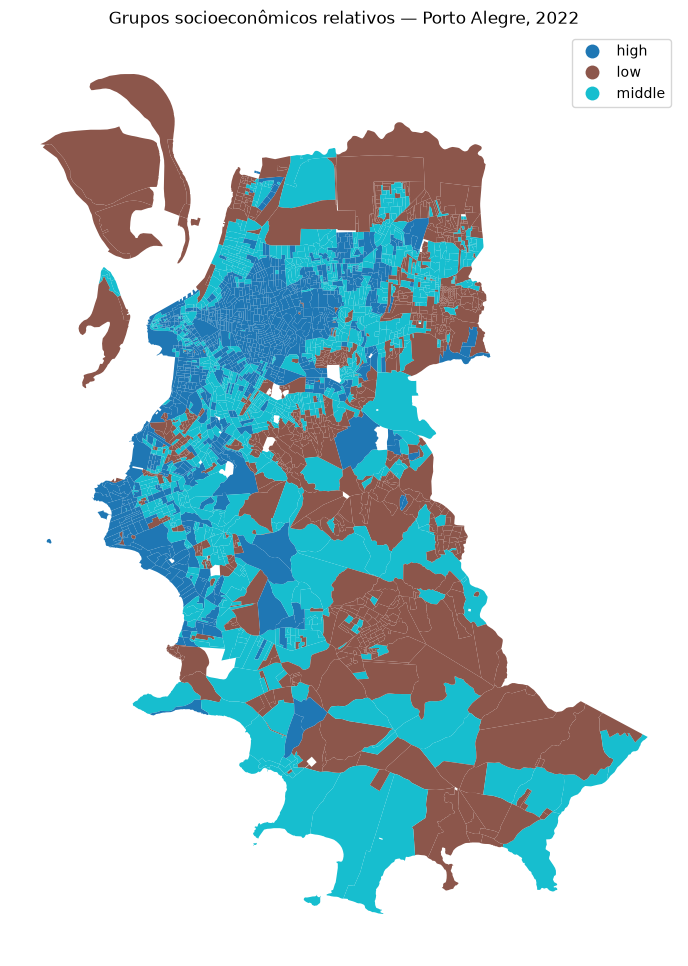

In [70]:
# Visualiza a distribuição espacial dos três grupos socioeconômicos em Porto Alegre

ax = setores_income.plot(
    column="income_group",
    categorical=True,
    legend=True,
    figsize=(12, 12),
    linewidth=0.15,
    edgecolor="none"
)

ax.set_axis_off()

ax.set_title(
    "Grupos socioeconômicos relativos — Porto Alegre, 2022"
)

Inspeção de tabelas

In [71]:
# ============================================================
# INSPEÇÃO DAS TABELAS DE ÁREAS DE PONDERAÇÃO
# ============================================================

from pathlib import Path
import pandas as pd


AREAS_PONDERACAO_DIR = (
    PROJECT_ROOT
    / "data"
    / "censo_2022"
    / "areas_ponderacao"
    / "tabelas_xlsx"
)


arquivos_apon = sorted(
    AREAS_PONDERACAO_DIR.rglob("*.xlsx")
)


print(
    f"Arquivos encontrados: {len(arquivos_apon)}"
)


for arquivo in arquivos_apon:
    print(
        arquivo.relative_to(
            AREAS_PONDERACAO_DIR
        )
    )

Arquivos encontrados: 0


In [72]:
# Eu procuro arquivos cujo nome indique
# alguma relação com renda ou rendimento.

arquivos_renda_apon = [
    arquivo
    for arquivo in arquivos_apon
    if any(
        termo in arquivo.name.lower()
        for termo in [
            "renda",
            "rendimento",
            "8.1",
            "8.2",
            "8.3",
            "8_1",
            "8_2",
            "8_3"
        ]
    )
]


for arquivo in arquivos_renda_apon:
    print(
        arquivo.name
    )